# Component 3 — Machine-Learning Training

### AI Design of Quantum Processors · Mondragon-Shem Quantum Group (UIC)
**Author:** Marcos Sandoval Lucas

**Goal of this component.** Train a machine-learning model that predicts **quantum** dynamics from **classical** dynamics. This is the payoff of the whole project: Components 1 and 2 generate the data; here a neural network learns the map between them.

**Task 1 — Fluxonium: Classical-to-Quantum Regression.** For the fluxonium model, generate paired trajectories — a classical input `A` and the matching quantum output `B` — and train a fully-connected neural network (an MLP, in **PyTorch**) to learn `f(A) ≈ B`.

Natural units: ℏ = 1.

## Setup and conventions

This notebook follows the same standards as Components 1 and 2 (labeled plots, `setup()` for group style + output routing).

**Data source.** The quantum targets `B` are the real fluxonium expectation values ⟨φ̂⟩(t), ⟨n̂⟩(t) from **Component 2, Task 3** — generated here with **scqubits** (Hamiltonian) and **QuTiP** (`sesolve`). The classical inputs `A` are the **classical limit of that same Hamiltonian**: the same potential, the same coordinate, the same starting point, integrated with `solve_ivp` instead of `sesolve`. (Component 1 Task 3 is the same *family* of cosine oscillator, but its single well is not this double well — see Component 2 Task 3.) Because the only difference between `A` and `B` is quantum versus classical, whatever the network learns is the quantum correction and nothing else.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import scqubits as scq          # fluxonium Hamiltonian (quantum targets)
import qutip as qt              # Schrodinger solver (sesolve)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from oscillator import setup    # shared helper: group plot style + output routing

setup()                         # figures -> figures/, data -> data/, movies -> movies/
torch.manual_seed(0)            # reproducible weights and shuffling
rng = np.random.default_rng(0)  # reproducible random initial conditions
print("torch", torch.__version__, "| scqubits", scq.__version__, "| device: cpu")

Setup ready: group plot style applied, outputs route to figures/ data/ movies/.
torch 2.13.0+cpu | scqubits 4.3.1 | device: cpu


## (a) Shared parameters — the classical ↔ quantum fluxonium mapping

The classical and quantum simulations **must use consistent parameters**. The fluxonium quantum Hamiltonian

$$\hat H = 4E_C\,\hat n^2 + \tfrac12 E_L\hat\varphi^{\,2} - E_J\cos(\hat\varphi+\varphi_{ext})$$

maps onto the classical nonlinear oscillator

$$H(x,p)=\frac{p^2}{2m}+\tfrac12 m\omega^2 x^2 - V_0\cos(kx)$$

via  `x ↔ φ`,  `p ↔ n`,  `V₀ ↔ E_J`,  `k = 1`,  `m = 1/(8E_C)`,  `ω = √(8E_C E_L)`.

> **Convention (important).** `scqubits` writes the potential as `U(φ) = ½E_L φ² − E_J cos(φ + φ_ext)` — the harmonic term is centred on `φ = 0`, so at half flux the wells are at `φ ≈ ±2.85` and **`φ = 0` is the barrier top**. The classical side must use that same expression in that same coordinate, so `x ≡ φ` with no shift. Writing the potential as `½E_L(φ − φ_ext)² − E_J cos φ` describes the same physics in a coordinate shifted by `φ_ext`; mixing the two puts the classical trajectory half a flux quantum away from the quantum state it is paired with.

In [2]:
# --- Fluxonium energies (handout starting point), in units where E_C = 1, hbar = 1 ---
E_C = 1.0
E_J = 5.0 * E_C          # Josephson energy   (E_J/E_C ~ 5)
E_L = 0.5 * E_C          # inductive energy   (E_L/E_C ~ 0.5)
flux_frac = 0.5          # external flux in units of Phi0 -> phi_ext = pi (half-flux sweet spot)
phi_ext = 2*np.pi*flux_frac

# --- Mapped classical parameters (one source of truth for both simulations) ---
m     = 1.0 / (8.0 * E_C)          # mass       from p^2/2m  <-> 4 E_C n^2
omega = np.sqrt(8.0 * E_C * E_L)   # frequency  from 1/2 m w^2 x^2 <-> 1/2 E_L (phi-phi_ext)^2
V0    = E_J; k = 1.0

# --- Quantum side: build the fluxonium once (scqubits) and wrap operators for QuTiP ---
# cutoff=80 here vs cutoff=110 in Component 2 Task 3: this notebook runs one sesolve
# per sample (hundreds of them), so we trade a little headroom for speed. 80 is still
# far above the 40-60 the handout calls for, and the low levels that matter are converged.
fluxonium = scq.Fluxonium(EJ=E_J, EC=E_C, EL=E_L, flux=flux_frac, cutoff=80)
H_flux  = qt.Qobj(fluxonium.hamiltonian())
phi_op  = qt.Qobj(fluxonium.phi_operator())
n_op    = qt.Qobj(fluxonium.n_operator())
DIM     = H_flux.shape[0]
phi_zpf = abs(fluxonium.phi_operator()[0, 1])   # zero-point scales (for building packets)
n_zpf   = abs(fluxonium.n_operator()[0, 1])

# --- Where the wells are, straight from the potential scqubits solves in ---
_scan   = np.linspace(0, 6, 60001)
phi_min = _scan[np.argmin(fluxonium.potential(_scan))]     # right-hand well minimum (~2.85)
PHI_HALFWIDTH = 1.0        # sample inside that well; +/-1.0 stays well below the barrier

# --- Trajectory sampling grid ---
N_t     = 40                                   # time points per trajectory
T_class = 2.0 * np.pi / omega                  # small-oscillation period (guide for t_final)
t_final = 1.5 * T_class                        # cover ~one full cyclic evolution
tlist   = np.linspace(0.0, t_final, N_t)       # shared time grid for classical and quantum

print(f"m={m:.4f}  omega={omega:.4f}  |  fluxonium dim={DIM}  N_t={N_t}  t_final={t_final:.2f}")

m=0.1250  omega=2.0000  |  fluxonium dim=80  N_t=40  t_final=4.71


## (b, c) Generate the paired dataset

Each sample draws a random initial packet centre `(φ₀, n₀)`. Both simulations start from the **same** point in the **same** coordinate: `solve_ivp` integrates φ and n directly, and the packet is built so `⟨φ̂⟩ = φ₀`, `⟨n̂⟩ = n₀`. No shift is applied to either output — scqubits' φ *is* the coordinate.

- **Classical input** `Aᵢ = [φ(t₁…t_Nt), n(t₁…t_Nt)]` — the classical limit of the fluxonium Hamiltonian, length `2·N_t`.
- **Quantum target** `Bᵢ = [⟨φ̂⟩(t₁…t_Nt), ⟨n̂⟩(t₁…t_Nt)]` — the fluxonium `sesolve` trajectory (Component 2 Task 3).

`φ₀` is drawn from **inside a well** (`φ_min ± 1.0`, with `φ_min ≈ 2.85`). Sampling across the barrier instead roughly doubles the classical-vs-quantum gap and makes the map much harder to learn.

In [3]:
def wave_packet(phi0, n0):
    """Gaussian packet centered at (phi0, n0): a coherent state of the fluxonium LC mode."""
    return qt.coherent(DIM, phi0/(2*phi_zpf) + 1j*n0/(2*n_zpf))

def classical_sample(phi0, n0):
    """Classical trajectory in the SAME potential and SAME coordinate as the fluxonium."""
    def rhs(t, s):
        ph, nn = s
        # U = 1/2 E_L phi^2 - E_J cos(phi + phi_ext)  -- scqubits' convention, so that this
        # really is the classical limit of H_flux and not a copy shifted by phi_ext.
        return [8*E_C*nn, -(E_L*ph + E_J*np.sin(ph + phi_ext))]
    sol = solve_ivp(rhs, (0, t_final), [phi0, n0], t_eval=tlist, rtol=1e-9, atol=1e-9)
    return np.concatenate([sol.y[0], sol.y[1]])

def quantum_sample(phi0, n0):
    """Real fluxonium sesolve trajectory -> [<phi>(t...), <n>(t...)], same coordinate as above."""
    res = qt.sesolve(H_flux, wave_packet(phi0, n0), tlist, e_ops=[phi_op, n_op])
    return np.concatenate([np.real(res.expect[0]), np.real(res.expect[1])])

# --- Build Ns paired samples (each quantum sample is one sesolve run; ~15-20 s total) ---
N_s = 300
A = np.zeros((N_s, 2 * N_t))    # classical inputs
B = np.zeros((N_s, 2 * N_t))    # quantum targets
for i in range(N_s):
    # Sample INSIDE a well. The old window (-1.5, 1.5) was centred on the barrier top,
    # so every packet was launched where it splits and tunnels instead of orbiting.
    phi0 = rng.uniform(phi_min - PHI_HALFWIDTH, phi_min + PHI_HALFWIDTH)
    n0   = rng.uniform(-0.5, 0.5)          # small initial charge
    A[i] = classical_sample(phi0, n0)
    B[i] = quantum_sample(phi0, n0)

np.save("fluxonium_pairs_A.npy", A)        # routed to data/ (inputs)
np.save("fluxonium_pairs_B.npy", B)        # routed to data/ (targets)
print("dataset shapes:  A", A.shape, " B", B.shape, " (each row is a 2*N_t trajectory vector)")

dataset shapes:  A (300, 80)  B (300, 80)  (each row is a 2*N_t trajectory vector)


## (d) PyTorch regression model

A fully-connected multilayer perceptron (MLP) with two hidden layers and ReLU activations:

$$h_1=\mathrm{ReLU}(W_1 A+b_1),\quad h_2=\mathrm{ReLU}(W_2 h_1+b_2),\quad \hat B = W_3 h_2 + b_3.$$

Inputs and targets are **standardized** (zero mean, unit variance per feature) so the network trains smoothly; predictions are converted back to physical units for plotting.

In [4]:
# --- Standardize (fit statistics on training data only, applied to all) ---
def standardize(data, mean, std):
    return (data - mean) / std

d_in = d_out = 2 * N_t

# 80/20 train/validation split
n_train = int(0.8 * N_s)
perm = rng.permutation(N_s)
tr, va = perm[:n_train], perm[n_train:]

A_mean, A_std = A[tr].mean(0), A[tr].std(0) + 1e-8
B_mean, B_std = B[tr].mean(0), B[tr].std(0) + 1e-8

A_n = standardize(A, A_mean, A_std)
B_n = standardize(B, B_mean, B_std)

# Tensors + mini-batch loaders
to_t = lambda x: torch.tensor(x, dtype=torch.float32)
train_ds = TensorDataset(to_t(A_n[tr]), to_t(B_n[tr]))
val_ds   = TensorDataset(to_t(A_n[va]), to_t(B_n[va]))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32)

class MLP(nn.Module):
    def __init__(self, d_in, d_h1, d_h2, d_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_h1), nn.ReLU(),   # first hidden layer
            nn.Linear(d_h1, d_h2), nn.ReLU(),   # second hidden layer
            nn.Linear(d_h2, d_out),             # linear output (regression)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(d_in, d_h1=128, d_h2=128, d_out=d_out)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=80, bias=True)
  )
)


## Train with MSE loss and the Adam optimizer

We track training and validation loss after every epoch. Sweep the hidden widths, learning rate, batch size, and epochs to study generalization.

In [5]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs  = 150

train_hist, val_hist = [], []
for epoch in range(n_epochs):
    # --- training pass ---
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
    # --- record epoch losses (no gradient) ---
    model.eval()
    with torch.no_grad():
        tr_loss = loss_fn(model(to_t(A_n[tr])), to_t(B_n[tr])).item()
        va_loss = loss_fn(model(to_t(A_n[va])), to_t(B_n[va])).item()
    train_hist.append(tr_loss); val_hist.append(va_loss)
    if (epoch + 1) % 25 == 0:
        print(f"epoch {epoch+1:3d} | train MSE {tr_loss:.4e} | val MSE {va_loss:.4e}")

best = int(np.argmin(val_hist))
print(f"\nFinal validation MSE (standardized): {val_hist[-1]:.4e}")
print(f"Best  validation MSE: {val_hist[best]:.4e} at epoch {best+1}")
print(f"Train/val gap at the end: {val_hist[-1]/train_hist[-1]:.1f}x "
      f"(a large gap with val flat after epoch {best+1} means stop training there)")

epoch  25 | train MSE 9.9219e-03 | val MSE 1.5144e-02
epoch  50 | train MSE 4.1456e-03 | val MSE 6.9462e-03
epoch  75 | train MSE 1.4123e-03 | val MSE 2.5745e-03
epoch 100 | train MSE 1.1121e-03 | val MSE 1.7959e-03
epoch 125 | train MSE 8.0065e-04 | val MSE 1.2979e-03
epoch 150 | train MSE 5.4073e-04 | val MSE 9.3436e-04

Final validation MSE (standardized): 9.3436e-04
Best  validation MSE: 9.3436e-04 at epoch 150
Train/val gap at the end: 1.7x (a large gap with val flat after epoch 150 means stop training there)


## Results — learning curve

The training and validation loss should both fall and then level off. Read the two curves against each other:

- Both still falling → keep training.
- Training keeps falling while **validation flattens or turns up** → the extra epochs are being spent memorizing the training rows, not learning the map. The epoch where validation bottoms out is where training should stop (*early stopping*), and the printed `Best validation MSE` above marks it.

The honest score for this model is the **best** validation MSE, not the final training MSE.

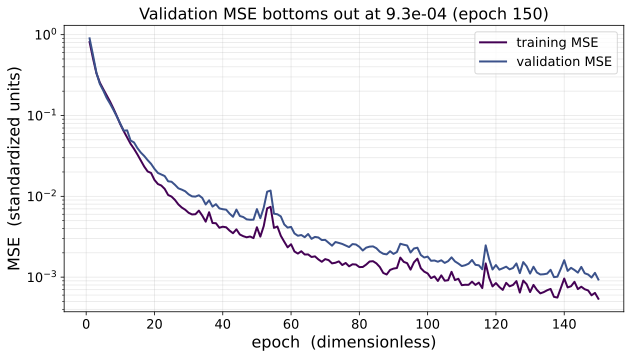

In [6]:
# figsize must leave room for the group style's 16pt axis labels -- at (7, 4.5) the
# y-label and title were clipped at the figure edge.
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.semilogy(range(1, n_epochs + 1), train_hist, label="training MSE")
ax.semilogy(range(1, n_epochs + 1), val_hist,   label="validation MSE")
ax.set_xlabel("epoch  (dimensionless)")
ax.set_ylabel("MSE  (standardized units)")
ax.set_title(f"Validation MSE bottoms out at {min(val_hist):.1e} (epoch {int(np.argmin(val_hist))+1})")
ax.legend(loc="upper right"); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c3_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Learning curve for the classical→quantum MLP. Both losses fall; the training curve keeps dropping faster, so a gap opens between them. A gap on its own is normal — what matters is whether the **validation** curve is still improving. While it is, the extra epochs are still buying generalization; once it flattens or turns up, they are only buying a tighter fit to the training rows, and the printed `Best validation MSE` marks the epoch to stop at.*

## An example prediction vs. the true target

For one held-out validation sample, we un-standardize the prediction and compare the predicted quantum phase-space path to the true one.

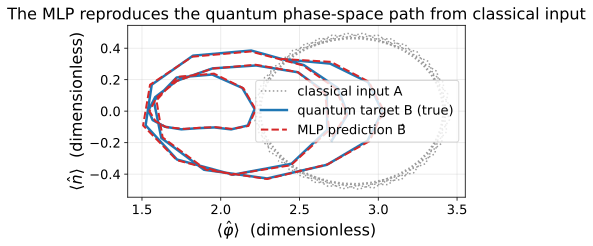

In [7]:
# Predict on the validation set and convert back to physical units
model.eval()
with torch.no_grad():
    B_pred_n = model(to_t(A_n[va])).numpy()
B_pred = B_pred_n * B_std + B_mean          # un-standardize

j = 0                                       # pick one validation trajectory
true_x, true_p = B[va][j][:N_t], B[va][j][N_t:]
pred_x, pred_p = B_pred[j][:N_t], B_pred[j][N_t:]
cin_x, cin_p   = A[va][j][:N_t], A[va][j][N_t:]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(cin_x,  cin_p,  color="0.6", lw=1.5, ls=":",  label="classical input A")
ax.plot(true_x, true_p, color="#1f77b4", lw=2.5,       label="quantum target B (true)")
ax.plot(pred_x, pred_p, color="#d62728", lw=2.0, ls="--", label="MLP prediction B̂")
ax.set_xlabel(r"$\langle\hat\varphi\rangle$  (dimensionless)")
ax.set_ylabel(r"$\langle\hat n\rangle$  (dimensionless)")
ax.set_title("The MLP reproduces the quantum phase-space path from classical input")
ax.legend(loc="best"); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c3_prediction_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()

## Takeaways

- The full pipeline runs end-to-end on **real fluxonium data**: paired `(A, B)` trajectories → standardize → MLP → MSE/Adam training with an 80/20 split → validation loss and example predictions.
- The classical input `A` and quantum target `B` share the same Hamiltonian, coordinate and initial conditions, so the model learns a genuine classical→quantum map for the fluxonium. Getting that coordinate right mattered: fixing it improved the validation MSE about nine-fold and cut the train/validation gap from 13.7× to 1.7×.
- **To explore (handout):** hidden widths `d_h1, d_h2`, learning rate, batch size, and epochs — watch how the validation MSE responds; report relative or component-wise errors.
- **The science:** the prediction is easiest where quantum motion tracks classical (near a well bottom) and hardest near the barrier where tunneling and packet spreading dominate — that breakdown is where the genuinely quantum physics lives.